Test F($\psi$) fitting

[19 12 13 11 10 15 13 10 19 17 15 14]


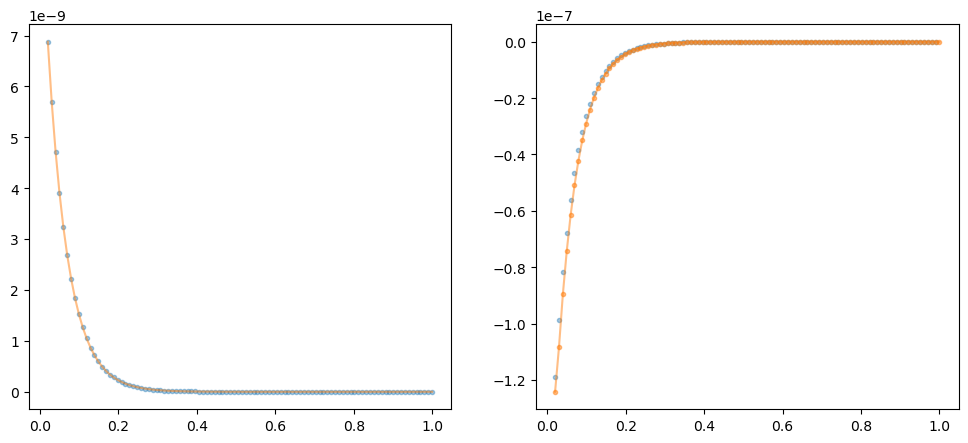

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# create test function
Np = 12
ncontours = 100
coeffs = np.random.randint(10,20,Np)

mu = np.zeros(ncontours)

for i in range(ncontours):
    mu[i] = (ncontours - i)/(ncontours + 1)

xx = 1 - mu**2
# xx[0] = 0.8*x[1]
x = np.linspace(xx[0], 1,ncontours)
# x=np.sort(x)

# y = np.polynomial.polynomial.polyval(x, coeffs)
y = 1.e-8*np.exp(-x*coeffs[0])

# print coeffs
print(coeffs)

# fit polynomial
y_fit = np.polynomial.polynomial.polyfit(np.log(x[:]),y[:],deg=Np)
y_eval = np.polynomial.polynomial.polyval(np.log(x),y_fit)

# find derivative
dy_coeffs = np.polynomial.polynomial.polyder(y_fit, m=1)
dy_eval = np.polynomial.polynomial.polyval(np.log(x),dy_coeffs)/x

y_fd = (y[1:] - y[:-1])/(x[1:]- x[:-1])
# print(dy_coeffs)

# plot
fig,(ax,ax_d) = plt.subplots(1,2, figsize = (12,5))
ax.plot((x),y, '.', alpha = 0.4)
ax.plot((x),y_eval,'-', alpha = 0.5)
ax_d.plot((x[:-1]),y_fd, '.', alpha = 0.4)
ax_d.plot((x),dy_eval, '.-', alpha = 0.5)
plt.show()


Notes:
- Observe that the fitting algorithm has difficulty when the points are constructed by placing several close to the end. 
- Think about how to space the points such that there is a nice fit. Need to consider: a) points are spaced at equal points in mu, and $\psi_i = (1 - \mu_i^2)$, so it may be better to equally space points in equal psi spacing?
- Why is it beneficial to space equally in mu?

Try with scipy.interpolate.UnivariateSpline fitting: [link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.UnivariateSpline.derivative.html)

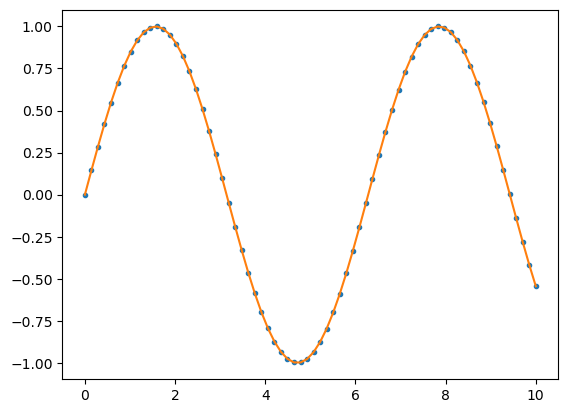

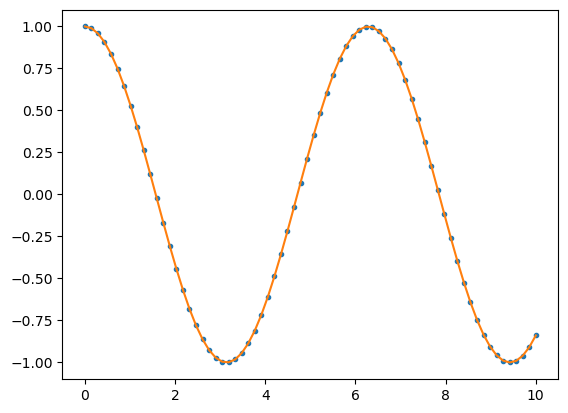

In [11]:
from scipy.interpolate import UnivariateSpline
u = np.linspace(0, 10, 70)
v = np.sin(u)
spl = UnivariateSpline(u, v, k=4, s=0)
fig,ax = plt.subplots()
ax.plot(u,v,'.')
ax.plot(u,spl(u))
plt.show()

deriv = spl.derivative()
fig,ax = plt.subplots()
ax.plot(u,np.cos(u), '.')
ax.plot(u,deriv(u))
plt.show()

Try with data:

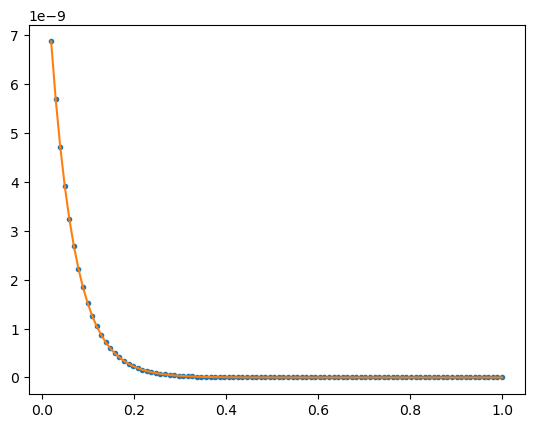

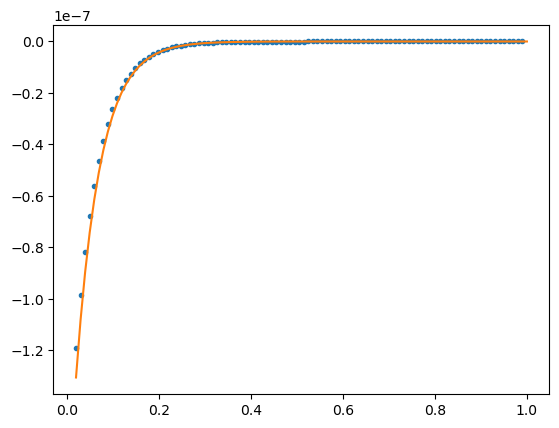

In [15]:
spl_data = UnivariateSpline(x,y, k=4,s=0)
fig,ax = plt.subplots()
ax.plot(x,y,'.')
ax.plot(x,spl_data(x))
plt.show()

deriv_data = spl_data.derivative()
fig,ax = plt.subplots()
ax.plot(x[:-1],y_fd, '.')
ax.plot(x,deriv_data(x))
plt.show()